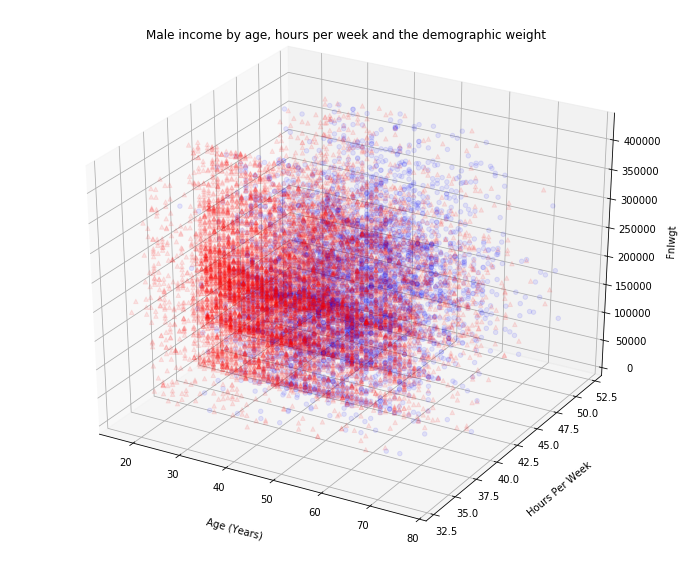

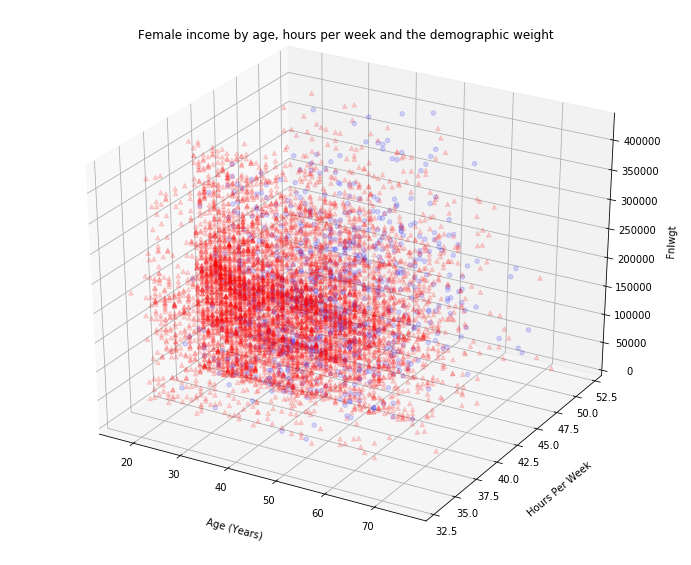

In [8]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt
import sqlite3 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt
import pandas
import random
 


columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
df = pd.read_csv("adult.data.txt", header=None, delimiter=', ', engine='python', names=columns);

limits = {}
desc = df.describe()

for val in ["age", "hours-per-week", "fnlwgt"]:
    Q3 = df.describe()[val]["75%"]
    Q1 = df.describe()[val]["25%"]
    IQR = Q3 - Q1
    
    limits[val] = [Q3 + 1.5 * IQR, Q1 - 1.5 * IQR]

scount = 0
for sex in ["Male", "Female"]:
    scount = scount + 1
    redX = []
    redY = []
    redZ = []

    blueX = []
    blueY = []
    blueZ = []

    random.seed(9001)

    for index, row in df.iterrows():
        if row["sex"] != sex:
            continue

        ageIsValid = limits["age"][0] > row["age"] and limits["age"][1] < row["age"]
        hoursPerWeekAreValid = limits["hours-per-week"][0] > row["hours-per-week"] and limits["hours-per-week"][1] < row["hours-per-week"]
        fnIsValid = limits["fnlwgt"][0] > row["fnlwgt"] and limits["fnlwgt"][1] < row["fnlwgt"]
        
        if ageIsValid and hoursPerWeekAreValid and fnIsValid:
            xs = row["age"]
            ys = row["hours-per-week"]
            zs = row["fnlwgt"]
            marker = '^'
            color = 'red'
            if row["income"] == '>50K':
                blueX.append(xs)
                blueY.append(ys)
                blueZ.append(zs)
            else:
                redX.append(xs)
                redY.append(ys)
                redZ.append(zs)

    plt.rcParams['figure.figsize'] = [12, 10]
    fig = plt.figure(scount)
    ax = fig.add_subplot(111, projection='3d')

    
    alpha = 900.0/len(redX)
    
    ax.scatter(redX, redY, redZ, c='red', marker='^', alpha=alpha)
    ax.scatter(blueX, blueY, blueZ, c='blue', marker='o', alpha=alpha)
    ax.set_xlabel('Age (Years)')
    ax.set_ylabel('Hours Per Week')
    ax.set_zlabel('Fnlwgt')

    ax.tick_params(axis='z', pad=10)


    ax.xaxis.labelpad = 20
    ax.yaxis.labelpad = 20
    ax.zaxis.labelpad = 20

    plt.title(sex + ' income by age, hours per week and the demographic weight', pad=15)

    plt.show()


